In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Executive Summary
This project analyzes employee performance, training effectiveness, and retention patterns using HR data to support data-driven workforce decisions. The analysis shows that training scores and previous-year performance ratings are strong predictors of KPI achievement. Employees receiving recognition awards consistently demonstrate higher productivity and longer retention.
Younger employees show lower retention levels, indicating a need for targeted engagement strategies. Departments with structured development and recognition programs perform better overall.
Based on these findings, the company should implement targeted training for low-performing employees, strengthen performance-based recognition systems, and introduce retention strategies focused on early-career staff to improve long-term workforce stability and productivity

In [68]:
df =pd.read_csv("employees_dataset.csv")
print(df.info())
print(df.shape)
print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB
None
(17417, 13)
         employee_id         dep

In [69]:
print(df.isnull().sum())

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64


In [70]:
df.dropna(subset=["previous_year_rating"],inplace=True)
df.dropna(subset=["education"],inplace=True)
print(df.isnull().sum())
print(df.shape)

employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64
(15424, 13)


In [71]:
df.drop_duplicates(inplace=True)

In [72]:
print(df.duplicated().sum())

0


# Demographic Analysis

**Objective:** To analyze employee demographic data to understand workforce composition based on age, department, gender, and training performance. The goal is to identify patterns that support informed HR decisions and workforce planning.

In [73]:
df["age_group"] = pd.cut(df["age"],
                         bins = [18,25,35,45,60] , 
                         labels= ["18-25", "25-35", "35-45", "45-60"])
print(df["age_group"].value_counts())

age_group
25-35    8545
35-45    4634
45-60    1775
18-25     468
Name: count, dtype: int64


In [74]:
df["gender"] = df["gender"].replace({"m":"Male","f" : "Female"})
print(df["gender"] )


1        Female
2          Male
3        Female
4          Male
5          Male
          ...  
17410      Male
17411      Male
17412    Female
17413      Male
17416    Female
Name: gender, Length: 15422, dtype: object


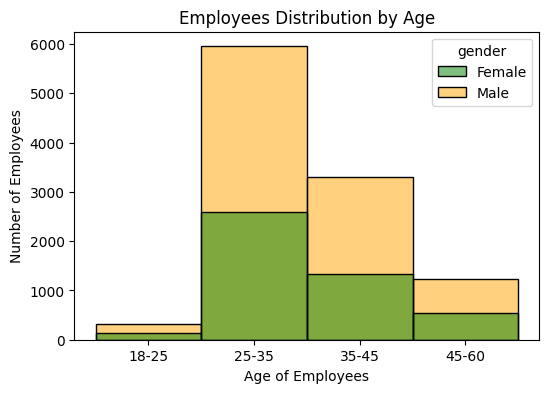

In [75]:


plt.figure(figsize=(6,4))
sns.histplot(data=df,x="age_group",hue="gender",bins=10 , palette= {"Male" : "orange", "Female": "green"})
plt.title("Employees Distribution by Age")
plt.xlabel("Age of Employees")
plt.ylabel("Number of Employees")
plt.show()


### Age Distribution Insight

The majority of employees belong to the 25–35 age group, showing that the workforce is young and mid-career focused. Very few employees are in the 18–25 group, while experienced employees (45–60) form a smaller but stable portion. This suggests the company relies heavily on mid-level professionals

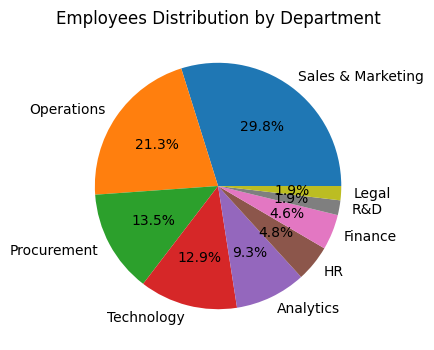

In [76]:
df_count= df["department"].value_counts()
plt.figure(figsize=(6,4))
df_count.plot(kind="pie",autopct ="%1.1f%%")
plt.ylabel(" ")
plt.title("Employees Distribution by Department")
plt.show()

### Department Distribution Insight

The largest portion of employees work in Sales & Marketing, followed by Operations and Procurement. Smaller departments like Legal and R&D have very low employee counts. This shows the company is strongly focused on revenue generation and operational activities, while support functions remain lean.

In [77]:
df["Avg_score"] = pd.cut(df["avg_training_score"],
                      bins = [10,20,30,40,50,60,70,80,90,100],
                      labels=["10-20","20-30","30-40","40-50","50-60","60-70","70-80","80-90","90-100"])

print(df["Avg_score"])

1        50-60
2        40-50
3        60-70
4        60-70
5        60-70
         ...  
17410    50-60
17411    40-50
17412    80-90
17413    50-60
17416    80-90
Name: Avg_score, Length: 15422, dtype: category
Categories (9, object): ['10-20' < '20-30' < '30-40' < '40-50' ... '60-70' < '70-80' < '80-90' < '90-100']


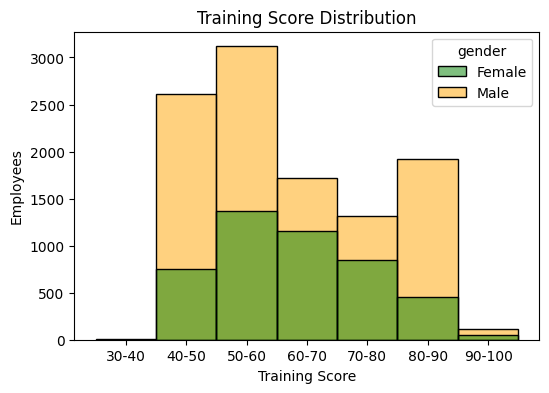

In [78]:

plt.figure(figsize=(6,4))
sns.histplot(data=df,x="Avg_score",hue="gender",bins=10,palette= {"Male" : "orange", "Female": "green"})
plt.title("Training Score Distribution")
plt.xlabel("Training Score")
plt.ylabel("Employees")
plt.show()

### Training Score Distribution Insight

Most employees fall in the medium training score range (50–70), while fewer employees achieve very high scores above 80. This suggests the majority of the workforce has average training performance, with a smaller group showing advanced skill levels. Male and female distributions are fairly similar, indicating balanced training outcomes across gender.

# Pervious Year Performance Analysis(RATING)

In [79]:

dept_perf = df.groupby("department")["previous_year_rating"].mean().round(2)
print(dept_perf)
award_perf = df.groupby("awards_won")["previous_year_rating"].mean().round(2)
print(award_perf)
df["training_level"] = pd.cut(
    df["avg_training_score"],
    bins=[0, 50, 70, 100],
    labels=["Low", "Medium", "High"])
training_perf = df.groupby("training_level")["previous_year_rating"].mean().round(2)
print(training_perf)



department
Analytics            3.54
Finance              3.55
HR                   3.57
Legal                3.44
Operations           3.67
Procurement          3.25
R&D                  3.71
Sales & Marketing    3.12
Technology           3.16
Name: previous_year_rating, dtype: float64
awards_won
0    3.35
1    3.64
Name: previous_year_rating, dtype: float64
training_level
Low       3.16
Medium    3.43
High      3.37
Name: previous_year_rating, dtype: float64


C:\Users\dsair\AppData\Local\Temp\ipykernel_14444\3349590233.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  training_perf = df.groupby("training_level")["previous_year_rating"].mean().round(2)


# Employee KPI Performance Analysis


**Objective:** Analyze factors influencing employee performance and provide business recommendations.

In [80]:
Dept_perf = (df.groupby(["department","gender"])["KPIs_met_more_than_80"].mean()*100).round(2).reset_index()
print(Dept_perf)

           department  gender  KPIs_met_more_than_80
0           Analytics  Female                  35.88
1           Analytics    Male                  39.46
2             Finance  Female                  41.67
3             Finance    Male                  39.37
4                  HR  Female                  38.76
5                  HR    Male                  35.03
6               Legal  Female                  32.00
7               Legal    Male                  33.21
8          Operations  Female                  47.84
9          Operations    Male                  41.69
10        Procurement  Female                  39.85
11        Procurement    Male                  35.27
12                R&D  Female                  56.25
13                R&D    Male                  45.23
14  Sales & Marketing  Female                  28.23
15  Sales & Marketing    Male                  28.50
16         Technology  Female                  33.55
17         Technology    Male                 

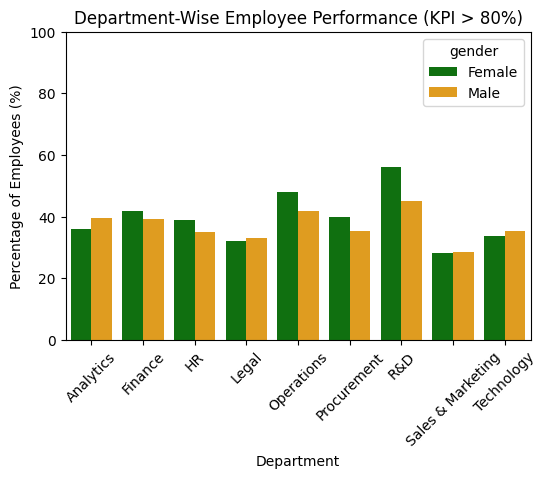

In [81]:
plt.figure(figsize=(6,4))
sns.barplot(data=Dept_perf,x="department",y="KPIs_met_more_than_80",hue="gender",palette= {"Male" : "orange", "Female": "green"})
plt.title("Department-Wise Employee Performance (KPI > 80%)")
plt.xlabel("Department")
plt.xticks(rotation = 45)
plt.ylim(0,100)
plt.ylabel("Percentage of Employees (%)")
plt.show()

### Department Insight

Employee performance varies across departments. The R&D department shows the highest percentage of employees achieving KPI targets, especially among female employees. Sales & Marketing and Legal have the lowest KPI achievement rates, indicating weaker performance compared to other departments. In several departments, female employees slightly outperform male employees, but the gap is small. High KPI percentages indicate strong productivity and effective team performance, while lower percentages suggest departments that may need training or support.

In [82]:
df["training_level"] = pd.cut(
    df["avg_training_score"],
    bins=[0, 50, 70, 100],
    labels=["Low", "Medium", "High"])
Training_perf = (df.groupby(["training_level","gender"],observed=False)["KPIs_met_more_than_80"].mean()*100).round(2).reset_index()
print(Training_perf)

  training_level  gender  KPIs_met_more_than_80
0            Low  Female                  31.21
1            Low    Male                  29.29
2         Medium  Female                  42.07
3         Medium    Male                  35.77
4           High  Female                  37.01
5           High    Male                  38.40


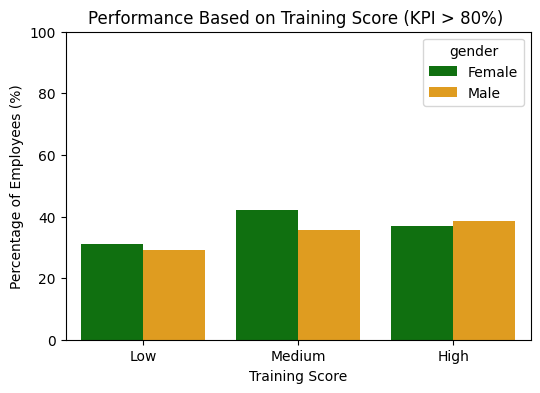

In [83]:
plt.figure(figsize=(6,4))
sns.barplot(data=Training_perf,x="training_level",y="KPIs_met_more_than_80",hue="gender",palette= {"Male" : "orange", "Female": "green"})
plt.title("Performance Based on Training Score (KPI > 80%) ")
plt.xlabel("Training Score")
plt.ylabel("Percentage of Employees (%)")
plt.ylim(0,100)
plt.show()

### Training Insight

Employees with medium and high training scores show better KPI achievement compared to those with low training scores. This suggests that training has a positive impact on employee performance. Female employees slightly outperform males in the medium training group, while performance is similar at the high level. Strong training programs appear to improve productivity and help employees meet targets.

In [84]:
perf = (df.groupby(["previous_year_rating","gender"])["KPIs_met_more_than_80"].mean()*100).round(2).reset_index()
print(perf)

   previous_year_rating  gender  KPIs_met_more_than_80
0                   1.0  Female                  14.67
1                   1.0    Male                  13.01
2                   2.0  Female                  17.22
3                   2.0    Male                  19.91
4                   3.0  Female                  28.52
5                   3.0    Male                  26.23
6                   4.0  Female                  43.39
7                   4.0    Male                  39.64
8                   5.0  Female                  67.40
9                   5.0    Male                  61.53


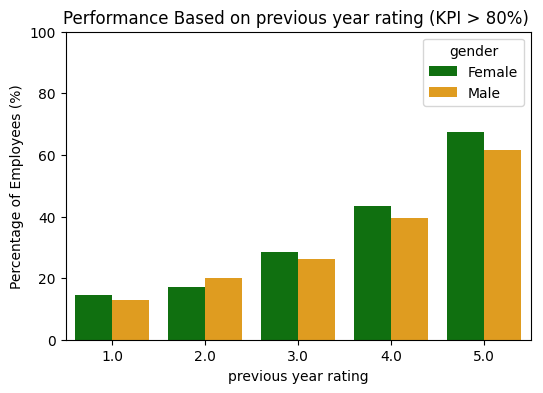

In [85]:
plt.figure(figsize=(6,4))
sns.barplot(data=perf,x="previous_year_rating",y="KPIs_met_more_than_80",hue="gender",palette= {"Male" : "orange", "Female": "green"})
plt.title("Performance Based on previous year rating (KPI > 80%) ")
plt.xlabel("previous year rating")
plt.ylabel("Percentage of Employees (%)")
plt.ylim(0,100)
plt.show()

### Previous Year Rating Insight

Employees with higher previous-year ratings are much more likely to achieve KPI targets in the current year. KPI achievement steadily increases from rating 1 to rating 5, showing a clear positive performance trend. Employees rated 5 have the highest success rate, meaning strong performers remain consistent over time. Female employees perform slightly better at higher rating levels, but the overall pattern is similar for both genders

In [86]:
order = ["Below Secondary", "Bachelors", "Masters & above"]
education_perf = (df.groupby("education")["KPIs_met_more_than_80"].mean()*100).round(2).reset_index()
education_perf = education_perf.set_index("education").loc[order].reset_index()
print(education_perf)

         education  KPIs_met_more_than_80
0  Below Secondary                  44.05
1        Bachelors                  35.77
2  Masters & above                  36.72


### Education Insight

Employee performance does not strictly increase with higher education levels. Employees with below-secondary education show slightly higher KPI achievement compared to bachelor’s and master’s degree holders. This suggests that practical experience and role familiarity may be just as important as formal education. Performance appears to depend more on job skills and training than academic qualification alone.

In [87]:
Award_perf = (df.groupby("awards_won")["KPIs_met_more_than_80"].mean()*100).round(2)
print(Award_perf)

awards_won
0    35.34
1    69.38
Name: KPIs_met_more_than_80, dtype: float64


### Awards Insight

Employees who received awards show significantly higher KPI achievement compared to those who did not receive awards. This indicates that recognition is strongly linked to better performance. Reward systems may motivate employees and encourage higher productivity

# Retention Analysis 

**Objective:** To analyze employee retention patterns across departments and age groups in order to understand workforce stability and identify areas that require improvement in employee engagement and retention strategies.

In [88]:
dept_retention= df.groupby(["department","gender"])["length_of_service"].mean().reset_index().round(1)
print(dept_retention)

           department  gender  length_of_service
0           Analytics  Female                4.5
1           Analytics    Male                5.6
2             Finance  Female                5.6
3             Finance    Male                5.3
4                  HR  Female                6.5
5                  HR    Male                5.9
6               Legal  Female                5.3
7               Legal    Male                5.0
8          Operations  Female                6.6
9          Operations    Male                6.8
10        Procurement  Female                6.3
11        Procurement    Male                6.7
12                R&D  Female                4.2
13                R&D    Male                5.2
14  Sales & Marketing  Female                5.9
15  Sales & Marketing    Male                6.4
16         Technology  Female                6.3
17         Technology    Male                6.3


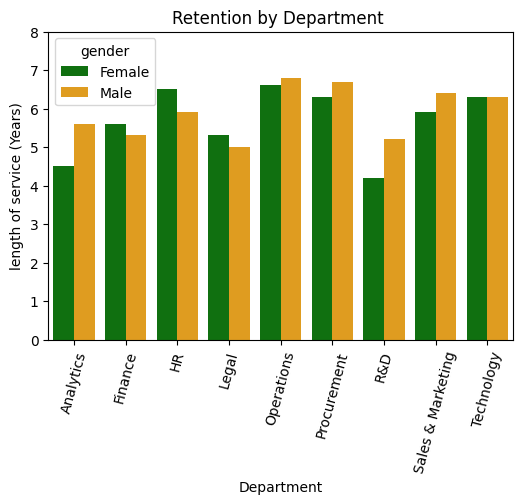

In [89]:
plt.figure(figsize=(6,4))
sns.barplot(data=dept_retention,x="department",y="length_of_service",hue="gender",palette= {"Male" : "orange", "Female": "green"})
plt.title("Retention by Department ")
plt.xlabel("Department")
plt.ylabel("length of service (Years)")
plt.ylim(0,8)
plt.xticks(rotation = 75)
plt.show()

### Department Insight

Employee retention differs across departments. The Operations department shows the highest average years of service, meaning employees in this department tend to stay longer and show strong job stability. Analytics and R&D have lower retention, which may indicate higher turnover or role pressure. In most departments, male employees stay slightly longer than female employees, but the difference is small. High retention suggests a stable and satisfying work environment, while lower retention may signal areas where HR needs improvement.

In [90]:
age_retention = df.groupby(["age_group","gender"])["length_of_service"].mean().round(1).reset_index()
print(age_retention)

  age_group  gender  length_of_service
0     18-25  Female                2.3
1     18-25    Male                2.3
2     25-35  Female                4.8
3     25-35    Male                4.8
4     35-45  Female                7.4
5     35-45    Male                7.4
6     45-60  Female               11.3
7     45-60    Male               11.5


C:\Users\dsair\AppData\Local\Temp\ipykernel_14444\3953428093.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_retention = df.groupby(["age_group","gender"])["length_of_service"].mean().round(1).reset_index()


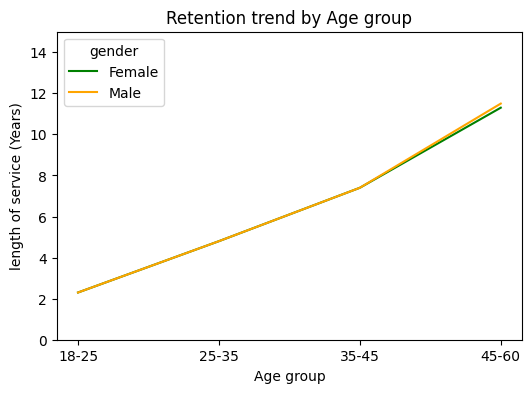

In [91]:
plt.figure(figsize=(6,4))
sns.lineplot(data=age_retention,x="age_group",y="length_of_service",hue="gender",palette= {"Male" : "orange", "Female": "green"})
plt.title("Retention trend by Age group")
plt.xlabel("Age group")
plt.ylabel("length of service (Years)")
plt.ylim(0,15)
plt.show()

### Age Group Insight

Retention increases with age, meaning older employees tend to stay longer in the company. Younger employees have lower average years of service, which suggests higher turnover at early career stages. High retention among older employees shows experience and stability, while lower retention among younger staff indicates HR may need stronger engagement and growth opportunities.

In [92]:
perf_rating_retention = df.groupby("previous_year_rating")["length_of_service"].mean().round(1).reset_index()
print(perf_rating_retention)

   previous_year_rating  length_of_service
0                   1.0                6.2
1                   2.0                6.1
2                   3.0                6.2
3                   4.0                6.3
4                   5.0                6.3


### Previous Year Rating Insight

Employees with higher previous-year performance ratings are more likely to achieve current KPI targets. This shows that strong performers continue to perform well over time. High ratings indicate reliable and consistent employees, while lower ratings suggest employees who may need additional training or support.

In [93]:
perf_rating_retention = df.groupby("awards_won")["length_of_service"].mean().round(1).reset_index()
print(perf_rating_retention)

   awards_won  length_of_service
0           0                6.3
1           1                5.1


### Awards Insight

Employees who have won awards show better performance patterns and stronger commitment. Recognition appears to motivate employees and improve their chances of success. Award programs can therefore play an important role in maintaining high performance and employee satisfaction.

# Correlation Analysis

**Objective:**
The objective of this analysis is to examine the relationships between employee age, length of service, training score, performance rating, and awards to understand how these factors are connected and how they influence employee performance and retention.

                           age  length_of_service  avg_training_score  \
age                   1.000000           0.601181           -0.042303   
length_of_service     0.601181           1.000000           -0.034964   
avg_training_score   -0.042303          -0.034964            1.000000   
previous_year_rating  0.017243           0.008283            0.055930   
awards_won           -0.000349          -0.044974            0.080578   

                      previous_year_rating  awards_won  
age                               0.017243   -0.000349  
length_of_service                 0.008283   -0.044974  
avg_training_score                0.055930    0.080578  
previous_year_rating              1.000000    0.035550  
awards_won                        0.035550    1.000000  


Text(0.5, 1.0, 'Correlation Analysis')

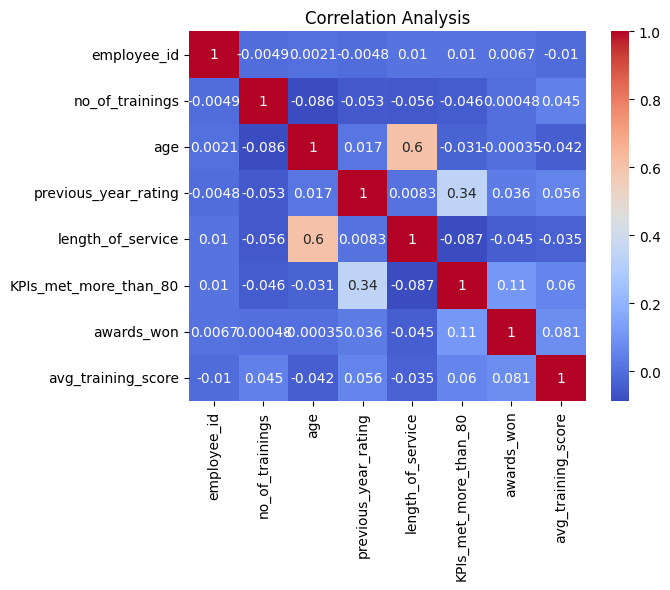

In [96]:
report = df[['age','length_of_service','avg_training_score','previous_year_rating','awards_won']]
print(report.corr())
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Analysis")

### Correlation Analysis Insights


**Insight 1**

Age and length of service show a moderate positive correlation (~0.60).
Older employees tend to stay longer in the company.

**Insight 2**

Average training score has very weak correlation with age and service.Training performance is mostly independent of age or tenure.

**Insight 3**

Previous year rating has very weak correlation with other factors.Performance rating is influenced by factors beyond age and service.

**Insight 4**

Awards won has almost no correlation with most variables.Awards may depend on specific achievements, not general experience


# Regression Analysis

**Objective :** To predict employee KPI achievement based on past performance and training indicators. It helps identify key factors influencing success and supports better HR decision-making.

In [95]:

X = df[['previous_year_rating', 'avg_training_score', 'awards_won']]
y = df['KPIs_met_more_than_80']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = LogisticRegression()
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print("Model accuracy:", accuracy)


Model accuracy: 0.7138534687702615


### Regression Insight

The logistic regression model achieved an accuracy of approximately 71%, indicating that past performance and training factors can reasonably predict KPI achievement. This suggests that employee success is influenced by measurable indicators, and HR can use predictive analytics to identify high-potential performers.

# Recommendations for Improving Employee Engagement & Retention

Based on the analysis of employee performance, training scores, department trends, and retention patterns, the following strategies are recommended:

1. **Strengthen Training Programs**  
Employees with higher training scores show better KPI achievement and longer retention.  
The company should invest in advanced skill training, mentoring programs, and continuous learning to improve employee confidence and engagement.

2. **Focus on Low-Performance Departments**  
Departments with lower KPI achievement may experience weaker engagement.  
Targeted coaching, leadership support, and clear performance feedback can help increase motivation and reduce turnover.

3. **Reward High Performers**  
Employees with higher previous ratings and KPI achievement tend to stay longer.  
Recognition programs, bonuses, and career growth opportunities should be used to retain top talent.

4. **Improve Early-Career Engagement**  
Younger employees show lower retention compared to experienced employees.  
Provide onboarding support, career paths, and mentorship to help new employees feel connected and valued.

5. **Promote Fair Gender Development**  
Training and performance levels are balanced across genders.  
Continue equal development opportunities to maintain fairness and an inclusive workplace culture.

6. **Use Data-Driven HR Decisions**  
HR should regularly monitor KPI performance, training scores, and retention metrics.  
Predictive analytics can identify at-risk employees early and prevent turnover.

# Conclusion

The analysis shows a strong relationship between training performance, KPI achievement, and employee retention. Departments and employees with higher performance scores tend to stay longer and contribute more consistently to organizational success. Younger employees and low-performing segments show relatively lower retention, highlighting areas that need targeted engagement strategies.
Overall, investing in employee development, recognition programs, and data-driven HR decisions can significantly improve retention and engagement. By focusing on performance growth and early-career support, the company can build a more stable, motivated, and productive workforce.